# Validation (2 datasets, 2 models)

In [1]:
# ── Chemins datasets ──────────────────────────────────────────────────────────
FIRST_DATASET_INPUTS   = "./Dorians/SHHQ-1.0/no_segment"
FIRST_DATASET_SEGMENTS = "./Dorians/SHHQ-1.0/segments"   # masques dérivés depuis ici

SECOND_DATASET_INPUTS  = "./ds/img"
SECOND_DATASET_OUTPUTS = "./ds/ann"
SECOND_SPLITS_DIR      = "./paupau/data/splits"  # split test généré par silhouette.ipynb

# ── Chemins modèles ───────────────────────────────────────────────────────────
MODEL_UNET_PATH   = "./Dorians/checkpoint/unet_segmentation/epoch-39.pth"
MODEL_RESNET_PATH = "./real_time/unet_segmentation+resnet.pth"

# ── Hyperparamètres d'évaluation ──────────────────────────────────────────────
N_SAMPLES  = 500    # images évaluées par dataset (None = tout le dataset)
BATCH_SIZE = 16
IMG_SIZE   = 512
THRESHOLD  = 0.5

In [2]:
import os, json, base64, io, zlib, random
from pathlib import Path

import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cuda


## 1. Architectures des modèles

In [3]:
# ── Model 1 : U-Net pur (epoch-39.pth) ───────────────────────────────────────
# Copié depuis src/not_pretrained/segmentation.ipynb
# Normalisation : /255 uniquement (via TF.to_tensor)
# Activation finale : sigmoid dans forward()

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs      = nn.ModuleList()
        self.ups        = nn.ModuleList()
        self.pool       = nn.MaxPool2d(2, 2)
        for f in features:
            self.downs.append(ConvBlock(in_channels, f)); in_channels = f
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.ups.append(ConvBlock(f * 2, f))
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips[-(i // 2 + 1)]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i + 1](x)
        return torch.sigmoid(self.final_conv(x))   # sigmoid inclus → sorties en [0,1]

print(f'UNet           : {sum(p.numel() for p in UNet().parameters())/1e6:.1f}M params')

# ── Model 2 : U-Net + ResNet34 (unet_segmentation+resnet.pth) ────────────────
# Copié depuis src/pretrained/silhouette.ipynb
# Normalisation : ImageNet (mean/std)
# Activation finale : aucune → logits bruts, sigmoid à appliquer à l'inférence

_tmp = smp.Unet(encoder_name='resnet34', encoder_weights=None, in_channels=3, classes=1, activation=None)
print(f'UNet+ResNet34  : {sum(p.numel() for p in _tmp.parameters())/1e6:.1f}M params')
del _tmp

UNet           : 31.0M params
UNet+ResNet34  : 24.4M params


## 2. Chargement des modèles

In [4]:
def _load_state(ckpt):
    """Extrait le state_dict depuis un checkpoint, quel que soit le format."""
    return ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt))

# Model 1 — U-Net pur
model_unet = UNet().to(device)
ckpt1 = torch.load(MODEL_UNET_PATH, map_location=device)
model_unet.load_state_dict(_load_state(ckpt1))
model_unet.eval()
epoch1   = ckpt1.get('epoch', '?')
dice1    = ckpt1.get('dice', None)
dice_str = f'{dice1:.4f}' if isinstance(dice1, float) else str(dice1)
print(f'✓ U-Net chargé         — epoch {epoch1} | dice train {dice_str}')

# Model 2 — U-Net + ResNet34
model_resnet = smp.Unet(encoder_name='resnet34', encoder_weights=None,
                        in_channels=3, classes=1, activation=None).to(device)
ckpt2 = torch.load(MODEL_RESNET_PATH, map_location=device)
model_resnet.load_state_dict(_load_state(ckpt2), strict=False)
model_resnet.eval()
epoch2   = ckpt2.get('epoch', '?')
iou2     = ckpt2.get('val_iou', None)
iou_str  = f'{iou2:.4f}' if isinstance(iou2, float) else str(iou2)
print(f'✓ U-Net+ResNet34 chargé — epoch {epoch2} | val_iou {iou_str}')

✓ U-Net chargé         — epoch 39 | dice train 0.9912
✓ U-Net+ResNet34 chargé — epoch ? | val_iou None


## 3. Datasets

In [5]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def preprocess_unet(imgs):
    """Preprocessing Model 1 : /255 seulement (TF.to_tensor s'en occupe déjà)."""
    return imgs   # déjà en [0, 1]

def preprocess_resnet(imgs):
    """Preprocessing Model 2 : normalisation ImageNet."""
    mean = IMAGENET_MEAN.to(imgs.device)
    std  = IMAGENET_STD.to(imgs.device)
    return (imgs - mean) / std

# ── Dataset 1 : SHHQ-1.0 ─────────────────────────────────────────────────────
# Masque dérivé : pixels de segments/ avec sum(RGB) > 15 → foreground
class Dataset1(Dataset):
    def __init__(self, noseg_dir, seg_dir, filenames):
        self.noseg_dir = noseg_dir
        self.seg_dir   = seg_dir
        self.filenames = filenames

    def __len__(self): return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img  = Image.open(os.path.join(self.noseg_dir, fname)).convert('RGB')
        img  = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)

        seg  = Image.open(os.path.join(self.seg_dir, fname)).convert('RGB')
        seg  = seg.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        mask = (np.array(seg).astype(np.float32).sum(axis=2) > 15).astype(np.float32)

        return TF.to_tensor(img), torch.tensor(mask).unsqueeze(0)   # [3,H,W] [0,1], [1,H,W]

# ── Dataset 2 : AISegment ─────────────────────────────────────────────────────
# Masque encodé : base64 → zlib → PNG palette (format Supervisely)
def _decode_bitmap(data, origin, img_h, img_w):
    bmp  = Image.open(io.BytesIO(zlib.decompress(base64.b64decode(data)))).convert('L')
    arr  = np.array(bmp)
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    ox, oy = origin[0], origin[1]
    bh, bw = arr.shape
    y2, x2 = min(oy + bh, img_h), min(ox + bw, img_w)
    mask[oy:y2, ox:x2] = (arr[:y2-oy, :x2-ox] > 127).astype(np.uint8)
    return mask

def _load_mask_ds2(ann_path):
    ann  = json.loads(Path(ann_path).read_text())
    h, w = ann['size']['height'], ann['size']['width']
    mask = np.zeros((h, w), dtype=np.uint8)
    for obj in ann['objects']:
        if obj['geometryType'] == 'bitmap' and obj['classTitle'] == 'human':
            mask = np.maximum(mask, _decode_bitmap(
                obj['bitmap']['data'], obj['bitmap']['origin'], h, w))
    return mask

class Dataset2(Dataset):
    def __init__(self, img_dir, ann_dir, filenames):
        self.img_dir  = Path(img_dir)
        self.ann_dir  = Path(ann_dir)
        self.filenames = filenames   # sans extension

    def __len__(self): return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]
        img  = Image.open(self.img_dir / f'{name}.jpg').convert('RGB')
        img  = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)

        mask_raw = _load_mask_ds2(self.ann_dir / f'{name}.jpg.json')
        mask = np.array(Image.fromarray(mask_raw * 255).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)) > 127

        return TF.to_tensor(img), torch.tensor(mask.astype(np.float32)).unsqueeze(0)

In [6]:
# ── Préparation Dataset 1 ─────────────────────────────────────────────────────
all_ds1 = sorted([
    f for f in os.listdir(FIRST_DATASET_INPUTS)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    and os.path.exists(os.path.join(FIRST_DATASET_SEGMENTS, f))
])
sample_ds1 = random.sample(all_ds1, min(N_SAMPLES or len(all_ds1), len(all_ds1)))
loader_ds1 = DataLoader(
    Dataset1(FIRST_DATASET_INPUTS, FIRST_DATASET_SEGMENTS, sample_ds1),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)
print(f'Dataset 1 (SHHQ-1.0)  : {len(sample_ds1)} images — {len(loader_ds1)} batches')

# ── Préparation Dataset 2 ─────────────────────────────────────────────────────
# Priorité au split test de silhouette.ipynb pour éviter le data leakage
splits_path = Path(SECOND_SPLITS_DIR) / 'test.txt'
if splits_path.exists():
    all_ds2 = splits_path.read_text().splitlines()
    print(f'Split test trouvé ({splits_path}) : {len(all_ds2)} images')
else:
    all_ds2 = [p.name.replace('.jpg.json', '') for p in sorted(Path(SECOND_DATASET_OUTPUTS).glob('*.jpg.json'))]
    print(f'Split test absent → toutes les annotations : {len(all_ds2)} images')

sample_ds2 = random.sample(all_ds2, min(N_SAMPLES or len(all_ds2), len(all_ds2)))
loader_ds2 = DataLoader(
    Dataset2(SECOND_DATASET_INPUTS, SECOND_DATASET_OUTPUTS, sample_ds2),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)
print(f'Dataset 2 (AISegment)  : {len(sample_ds2)} images — {len(loader_ds2)} batches')

Dataset 1 (SHHQ-1.0)  : 500 images — 32 batches
Split test trouvé (paupau/data/splits/test.txt) : 4054 images
Dataset 2 (AISegment)  : 500 images — 32 batches


## 4. Évaluation — Dice sur les 4 combinaisons

In [7]:
@torch.no_grad()
def evaluate(model, loader, preprocess_fn, desc='eval'):
    """
    Calcule le Dice moyen sur un dataloader.
    - model        : le modèle PyTorch (eval mode)
    - loader       : DataLoader retournant (imgs [0,1], masks)
    - preprocess_fn: fonction appliquée sur imgs avant le forward (normalisation)
    - desc         : label pour tqdm
    """
    smooth = 1e-5
    total_dice = 0.0
    n = 0

    for imgs, masks in tqdm(loader, desc=desc, leave=True):
        imgs  = preprocess_fn(imgs.to(device))
        masks = masks.to(device)

        preds = model(imgs)
        # Model 2 sort des logits bruts → sigmoid
        if preds.min() < 0 or preds.max() > 1:
            preds = torch.sigmoid(preds)

        pred_bin = (preds > THRESHOLD).float()

        # Dice par image puis accumulation
        inter = (pred_bin * masks).view(len(imgs), -1).sum(dim=1)
        union = pred_bin.view(len(imgs), -1).sum(dim=1) + masks.view(len(imgs), -1).sum(dim=1)
        batch_dice = ((2.0 * inter + smooth) / (union + smooth)).sum().item()

        total_dice += batch_dice
        n += len(imgs)

    return total_dice / n

In [8]:
print('=== Évaluation Dice — 2 modèles × 2 datasets ===\n')

results = {}

# (1) U-Net pur × Dataset 1  ← combinaison native (même entraînement)
print('[ 1/4 ] U-Net (epoch-39) sur Dataset 1 (SHHQ-1.0) ...')
results[('unet', 'ds1')] = evaluate(model_unet, loader_ds1, preprocess_unet,
                                     desc='UNet × DS1')
print(f'        Dice = {results[("unet","ds1")]:.4f}\n')

# (2) U-Net pur × Dataset 2  ← cross-dataset (pas de normalisation ImageNet)
print('[ 2/4 ] U-Net (epoch-39) sur Dataset 2 (AISegment) ...')
results[('unet', 'ds2')] = evaluate(model_unet, loader_ds2, preprocess_unet,
                                     desc='UNet × DS2')
print(f'        Dice = {results[("unet","ds2")]:.4f}\n')

# (3) ResNet × Dataset 1  ← cross-dataset
print('[ 3/4 ] U-Net+ResNet34 sur Dataset 1 (SHHQ-1.0) ...')
results[('resnet', 'ds1')] = evaluate(model_resnet, loader_ds1, preprocess_resnet,
                                       desc='ResNet × DS1')
print(f'        Dice = {results[("resnet","ds1")]:.4f}\n')

# (4) ResNet × Dataset 2  ← combinaison native
print('[ 4/4 ] U-Net+ResNet34 sur Dataset 2 (AISegment) ...')
results[('resnet', 'ds2')] = evaluate(model_resnet, loader_ds2, preprocess_resnet,
                                       desc='ResNet × DS2')
print(f'        Dice = {results[("resnet","ds2")]:.4f}\n')

print('Done.')

=== Évaluation Dice — 2 modèles × 2 datasets ===

[ 1/4 ] U-Net (epoch-39) sur Dataset 1 (SHHQ-1.0) ...


UNet × DS1:   0%|          | 0/32 [00:00<?, ?it/s]

        Dice = 0.9919

[ 2/4 ] U-Net (epoch-39) sur Dataset 2 (AISegment) ...


UNet × DS2:   0%|          | 0/32 [00:00<?, ?it/s]

        Dice = 0.6487

[ 3/4 ] U-Net+ResNet34 sur Dataset 1 (SHHQ-1.0) ...


ResNet × DS1:   0%|          | 0/32 [00:00<?, ?it/s]

        Dice = 0.9055

[ 4/4 ] U-Net+ResNet34 sur Dataset 2 (AISegment) ...


ResNet × DS2:   0%|          | 0/32 [00:00<?, ?it/s]

        Dice = 0.9925

Done.


## 5. Résultats

In [9]:
# ── Tableau récapitulatif ─────────────────────────────────────────────────────
header  = f"{'Modèle':<22} {'Dataset 1 (SHHQ)':>18} {'Dataset 2 (AISegment)':>22}"
sep     = '-' * len(header)
row_u   = f"{'U-Net pur (epoch-39)':<22} {results[('unet','ds1')]:>18.4f} {results[('unet','ds2')]:>22.4f}"
row_r   = f"{'U-Net + ResNet34':<22} {results[('resnet','ds1')]:>18.4f} {results[('resnet','ds2')]:>22.4f}"
note_u  = '(natif)' if results[('unet','ds1')] > results[('unet','ds2')] else ''
note_r  = '(natif)' if results[('resnet','ds2')] > results[('resnet','ds1')] else ''

print(f'\n{"Dice Scores":^{len(header)}}')
print(sep)
print(header)
print(sep)
print(row_u + f'  ← {note_u}' if note_u else row_u)
print(row_r + f'  ← {note_r}' if note_r else row_r)
print(sep)
print()
print('(natif) = dataset sur lequel le modèle a été entraîné')
print(f'Threshold = {THRESHOLD} | N_SAMPLES = {N_SAMPLES} par dataset')


                          Dice Scores                           
----------------------------------------------------------------
Modèle                   Dataset 1 (SHHQ)  Dataset 2 (AISegment)
----------------------------------------------------------------
U-Net pur (epoch-39)               0.9919                 0.6487  ← (natif)
U-Net + ResNet34                   0.9055                 0.9925  ← (natif)
----------------------------------------------------------------

(natif) = dataset sur lequel le modèle a été entraîné
Threshold = 0.5 | N_SAMPLES = 500 par dataset


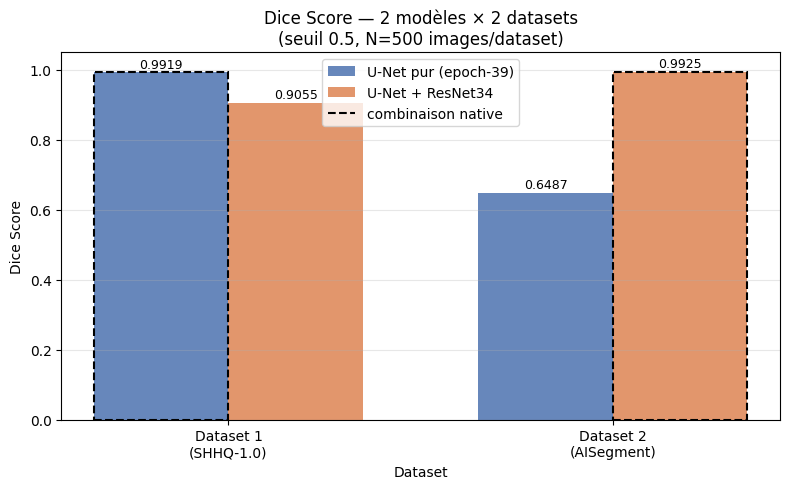

In [10]:
# ── Visualisation bar chart ───────────────────────────────────────────────────
labels   = ['Dataset 1\n(SHHQ-1.0)', 'Dataset 2\n(AISegment)']
unet_scores   = [results[('unet',   'ds1')], results[('unet',   'ds2')]]
resnet_scores = [results[('resnet', 'ds1')], results[('resnet', 'ds2')]]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_u = ax.bar(x - width/2, unet_scores,   width, label='U-Net pur (epoch-39)',  color='#4C72B0', alpha=0.85)
bars_r = ax.bar(x + width/2, resnet_scores, width, label='U-Net + ResNet34',      color='#DD8452', alpha=0.85)

# Annotations valeurs
for bar in bars_u:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars_r:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

# Encadrer la combinaison native (diagonale)
native = [(x[0] - width/2, unet_scores[0]),   # UNet × DS1
          (x[1] + width/2, resnet_scores[1])]  # ResNet × DS2
for bx, by in native:
    ax.add_patch(plt.Rectangle((bx - width/2, 0), width, by,
                                fill=False, edgecolor='black', linewidth=1.5, linestyle='--', zorder=5))

ax.set_xlabel('Dataset')
ax.set_ylabel('Dice Score')
ax.set_title(f'Dice Score — 2 modèles × 2 datasets\n(seuil {THRESHOLD}, N={N_SAMPLES} images/dataset)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, min(1.05, max(unet_scores + resnet_scores) + 0.08))
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Légende cadre natif
from matplotlib.lines import Line2D
ax.legend(handles=[
    *ax.get_legend_handles_labels()[0],
    Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='combinaison native')
])

plt.tight_layout()
plt.show()

In [ ]:
# ── Visualisation qualitative — exemples de prédictions ──────────────────────
N_EXAMPLES = 3   # nombre d'exemples par dataset

@torch.no_grad()
def get_examples(dataset, n):
    indices = random.sample(range(len(dataset)), n)
    imgs, masks = zip(*[dataset[i] for i in indices])
    imgs  = torch.stack(imgs)   # [N,3,H,W]
    masks = torch.stack(masks)  # [N,1,H,W]
    return imgs, masks

def predict(model, imgs, preprocess_fn):
    inp  = preprocess_fn(imgs.to(device))
    pred = model(inp)
    if pred.min() < 0 or pred.max() > 1:
        pred = torch.sigmoid(pred)
    return (pred > THRESHOLD).float().cpu()

# Données
ds1_ex_imgs, ds1_ex_masks = get_examples(Dataset1(FIRST_DATASET_INPUTS, FIRST_DATASET_SEGMENTS, sample_ds1), N_EXAMPLES)
ds2_ex_imgs, ds2_ex_masks = get_examples(Dataset2(SECOND_DATASET_INPUTS, SECOND_DATASET_OUTPUTS, sample_ds2), N_EXAMPLES)

ds1_unet_preds   = predict(model_unet,   ds1_ex_imgs, preprocess_unet)
ds1_resnet_preds = predict(model_resnet, ds1_ex_imgs, preprocess_resnet)
ds2_unet_preds   = predict(model_unet,   ds2_ex_imgs, preprocess_unet)
ds2_resnet_preds = predict(model_resnet, ds2_ex_imgs, preprocess_resnet)

# ── Figure ────────────────────────────────────────────────────────────────────
# Colonnes : Image | Masque GT | U-Net | ResNet34
# Lignes   : N_EXAMPLES × Dataset1, puis N_EXAMPLES × Dataset2

n_rows = N_EXAMPLES * 2
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5))
fig.subplots_adjust(hspace=0.05, wspace=0.05)

col_titles = ['Image', 'Masque GT', 'U-Net (epoch-39)', 'U-Net + ResNet34']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=8)

def to_np_img(t):
    """Tensor [3,H,W] ou [1,H,W] → numpy affichable."""
    t = t.squeeze().cpu().numpy()
    if t.ndim == 3:
        return np.clip(t.transpose(1, 2, 0), 0, 1)
    return t

dataset_labels = (
    ['DS1 (SHHQ)'] * N_EXAMPLES +
    ['DS2 (AISegment)'] * N_EXAMPLES
)
all_imgs   = [ds1_ex_imgs,   ds2_ex_imgs]
all_masks  = [ds1_ex_masks,  ds2_ex_masks]
all_unet   = [ds1_unet_preds,   ds2_unet_preds]
all_resnet = [ds1_resnet_preds, ds2_resnet_preds]

for ds_idx in range(2):
    for ex_idx in range(N_EXAMPLES):
        row = ds_idx * N_EXAMPLES + ex_idx
        img    = to_np_img(all_imgs[ds_idx][ex_idx])
        mask   = to_np_img(all_masks[ds_idx][ex_idx])
        pred_u = to_np_img(all_unet[ds_idx][ex_idx])
        pred_r = to_np_img(all_resnet[ds_idx][ex_idx])

        for col, data in enumerate([img, mask, pred_u, pred_r]):
            ax = axes[row, col]
            ax.imshow(data, cmap='gray' if data.ndim == 2 else None)
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(f'{dataset_labels[row]}\n#{ex_idx+1}',
                              fontsize=9, labelpad=4)

# Séparateur entre les deux datasets
for col in range(n_cols):
    axes[N_EXAMPLES - 1, col].spines['bottom'].set_linewidth(2.5)
    axes[N_EXAMPLES - 1, col].spines['bottom'].set_color('#333')

fig.suptitle(
    f'Exemples de prédictions — seuil {THRESHOLD}',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()